In [1]:
from SPARQLWrapper import SPARQLWrapper, JSON

# Get from AERIS Catalogue mapping EXV to CF (P07).
# To replace with NERC catalogue when P07 I-ADOPT mapping done.
# Test for ECV precursors --> carbon monoxide in IAGOS.
sparql = SPARQLWrapper("https://skosmos.aeris-data.fr/sparql")
sparql.setReturnFormat(JSON)
sparql.setQuery("""
   PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
SELECT * FROM <https://vocab.aeris-data.fr/parameter>
WHERE {
  ?param skos:relatedMatch <http://vocab.nerc.ac.uk/collection/EXV/current/EXV015/> .
  ?param skos:narrowMatch ?o .
} 
    """)
try:
    retEXV = sparql.queryAndConvert()
    for r in retEXV["results"]["bindings"]:
        print(r)
except Exception as e:
    print(e)

{'param': {'type': 'uri', 'value': 'https://vocab.aeris-data.fr/parameter/a2cbdc84-2129-7437-4a16-4d2d4f850ae4'}, 'o': {'type': 'uri', 'value': 'http://vocab.nerc.ac.uk/collection/P07/current/CFSN0817/'}}
{'param': {'type': 'uri', 'value': 'https://vocab.aeris-data.fr/parameter/c31f72a0-7737-8f30-8271-dcf843ebfb45'}, 'o': {'type': 'uri', 'value': 'http://vocab.nerc.ac.uk/collection/P07/current/CFSN0812/'}}


In [2]:
# Extract CF names from results.
sparql2 = SPARQLWrapper(
    "http://vocab.nerc.ac.uk/sparql/sparql"
)
sparql2.setReturnFormat(JSON)
# list of CF names.
variables = []
for r in retEXV["results"]["bindings"]:
    # gets the first 3 geological ages
    # from a Geological Timescale database,
    # via a SPARQL endpoint
    sparql2.setQuery("""
      PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
    PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
    PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
    SELECT * WHERE {
      <%s> skos:prefLabel ?obj .
    } 
        """ % r['o']['value']
    )
    try:
        retCF = sparql2.queryAndConvert()
        for b in retCF["results"]["bindings"]:
            variables.append(b['obj']['value'])
    except Exception as e:
        print(e)
print(variables)

['mole_fraction_of_nitrogen_dioxide_in_air', 'mole_fraction_of_carbon_monoxide_in_air']


In [3]:
# Mapping CF to IAGOS variables shortname.
# Update API to search by CF name.
mapping_CF_IAGOS = {'mole_fraction_of_carbon_monoxide_in_air' : ['CO'],
                   'mole_fraction_of_carbon_dioxide_in_air' : ['CO2']}

# Get airports matching the spatial extent.
# 1st step necessary, will be removed when search service updated (taking bbox instead of stations list).
import requests
import json
bbox="0,0,50,90"
parameters=[]
for x in mapping_CF_IAGOS:
    for y in mapping_CF_IAGOS[x]:
        parameters.append(y)
parameters=",".join(parameters)
start="2021-08-01"
end="2021-10-20"
indexPage=0
sizePage=20
url="https://services.iagos-data.fr/prod/v2.0/airports/public?active=true&bbox="+bbox+"&from="+start+"&to="+end+"&cursor="+str(indexPage)+"&size="+str(sizePage)
response=requests.get(url)
data = json.loads(response.text)
airports = []
for dataset in data:
    airports.append(dataset['iata_code'])
airports=",".join(airports)
print(airports)

MLE,PHL,BKK,DFW,ALA,TSE,JFK,MCO,MIA,ORD,DXB,DMM,SSG,KWI,IKA,SJO,FRA,ATL,NBO,IAH


https://services.iagos-data.fr/prod/v2.0/l3/search?codes=MLE,PHL,BKK,DFW,ALA,TSE,JFK,MCO,MIA,ORD,DXB,DMM,SSG,KWI,IKA,SJO,FRA,ATL,NBO,IAH&from=2021-08-01&to=2021-10-20&level=2&parameters=CO,CO2
https://services.iagos-data.fr/prod/v2.0/l3/loadNetcdfFile?fileId=https://doi.org/10.25326/638%23vp_daily_FRA.nc
<xarray.DataArray 'CO' (time: 10802)>
array([    nan,     nan,     nan, ..., 176.32 , 186.16 , 222.245],
      dtype=float32)
Coordinates:
    layer    <U4 '500m'
  * time     (time) datetime64[ns] 1994-08-01T12:00:00 ... 2024-02-26T12:00:00
Attributes:
    standard_name:  mole_fraction_of_carbon_monoxide_in_air
    long_name:      Daily median of carbon monoxide mixing ratio
    units:          ppb


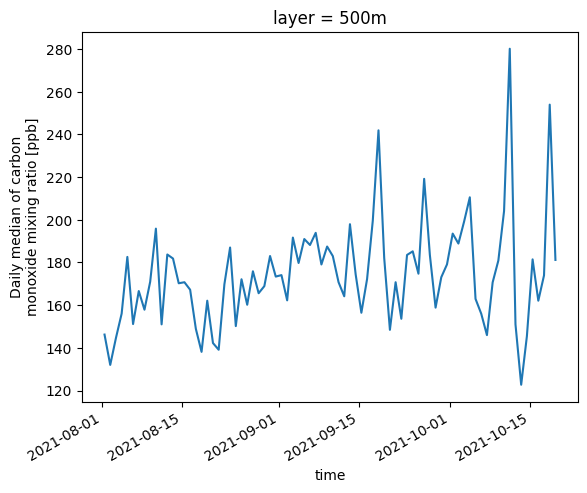

In [4]:
# For each airport, read data in xarray and load the relevant variables.
import io
import xarray as xr
import matplotlib.pyplot as plt
url="https://services.iagos-data.fr/prod/v2.0/l3/search?codes="+airports+"&from="+start+"&to="+end+"&level=2&parameters="+parameters
print(url)
response=requests.get(url)
data = json.loads(response.text)
datasets = {}
for dataset in data:
    datasets[dataset['title']] = dataset

# Limiting to Frankfurt airport dataset for this test.
dataset=datasets['IAGOS Daily median profiles at FRA, Frankfurt, Germany airport (FRA)']
# Retrieving the endpoint dataset URI.
url = None
for _url_info in dataset['urls']:
    if _url_info['type'].upper() == 'LANDING_PAGE':
        url = _url_info['url']
# Loading the data.
urlDl="https://services.iagos-data.fr/prod/v2.0/l3/loadNetcdfFile?fileId=" + url.replace("#", "%23")
print(urlDl)
response = requests.get(urlDl)
response.raise_for_status()
with io.BytesIO(response.content) as buf:
    with xr.open_dataset(buf) as ds:
        varlist = []
        for varname, da in ds.data_vars.items():
            if 'standard_name' not in da.attrs:
                continue
            std_name = da.attrs['standard_name']
            if std_name in variables:
                varlist.append(varname)
        ds = ds[varlist].load()
# Plotting the data.
# 4 layers available for each variable. Only reading the first level (surface).
# Subsetting by temporal extent used for searching.
for var in ds.data_vars:
    varData = ds.get(var)[0]
    print(varData)
    varPlot = varData.sel(time=slice(start, end))
    varPlot.plot()